Import Libraries

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh

Download dataset from kaggle then save to a dataframe

In [ ]:
path = kh.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")
filename = "/multiple_linear_regression_dataset.csv"
df = pd.read_csv(path + filename)
df.head()

Using Colab cache for faster access to the 'multiple-linear-regression-dataset' dataset.


,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


check the size of the data

In [ ]:
df.shape

(20, 3)

we change the fields from series to numpy arrays

In [ ]:
x1, x2, y = np.array(df['age']), np.array(df['experience']), np.array(df['income'])

checking to confirm

In [ ]:
x1

array([25, 30, 47, 32, 43, 51, 28, 33, 37, 39, 29, 47, 54, 51, 44, 41, 58,
       23, 44, 37])

Create Prediction Function where prediction is equal to gradients multiply x(s) plus constant

In [ ]:
# prediction

def pred (x1, x2, m1, m2, c):
    y = m1 * x1 + m2 * x2 + c

    return y

Create a Mean Square Error Function
MSE is the average of the diff between actual value and pred value this is squared

In [ ]:
#Cost Funtion
def mse (y_true, y_pred):
    # MSE is the average of the diff between actual value and pred value this is squared
    se = np.mean((y_true - y_pred) ** 2)

    return se

to get the gradient, we find the gradient with respect to slope(dm1), dm2 and intercept(dc) \
dj/dm1 = (-2/n) * sum(x1 * (error)) note: error = y_true - y_pred \
dj/dm2 = (-2/n) * sum(x2 * (error)) note: error = y_true - y_pred \
dj/dc = (-2/n) * sum(error)

In [ ]:


def gradient (x1, x2, y, m1, m2, c):

    n = x1.size  #size of the data
    y_hat = pred (x1, x2, m1, m2, c)
    error = y - y_hat
    dm1 = -2 * np.mean(x1 * error)
    dm2 = -2 * np.mean(x2 * error)
    dc = -2 * np.mean(error)

    return dm1, dm2, dc

we set our learning rate to 0.0001 and we set other parameters

In [ ]:
lr = 0.0001  #learning rate
m1 = 0
m2 = 0
c = 0

errors = []
ms1 = []
ms2 = []
cs = []

In [ ]:
#y_hat = pred(x1, x2, m1, m2, c)  #cal predicted values
#error = mse(y, y_hat)  #cal the cost function
#grad = gradient(x1, x2, y, m1, m2, c) #cal the gradrient

#errors.append(error)
#ms1.append(m1)
#ms2.append(m2)
#cs.append(c)

#adjust parameters
#m1 = m1 - lr * grad[0]
#m2 = m2 - lr * grad[1]
#c = c - lr * grad[2]

#print(f"The Gradient is: dM1 = {grad[0]}, dM2 = {grad[1]} and dC = {grad[2]}")
#print(f"The MSE is: {error}, M1 = {m1}, M2 = {m2} and C = {c}")



now we test our model using a loop \
we add our outputs to some list \
and we adjust our parameters

In [ ]:
for a in range (500000): # a loop to have multiple itirations
    y_hat = pred(x1, x2, m1, m2, c)  #cal predicted values
    error = mse(y, y_hat)  #cal the cost function
    grad = gradient(x1, x2, y, m1, m2, c) #cal the gradrient

    errors.append(error)
    ms1.append(m1)
    ms2.append(m2)
    cs.append(c)

    #adjust parameters
    m1 = m1 - lr * grad[0]
    m2 = m2 - lr * grad[1]
    c = c - lr * grad[2]

    print(f"The MSE is: {error}, M1 = {m1}, M2 = {m2} and C = {c}")




Streaming output truncated to the last 5000 lines.
The MSE is: 1535124.8975898302, M1 = -94.65052495308471, M2 = 2158.997429981313 and C = 31093.74228983363
The MSE is: 1535124.8661041816, M1 = -94.65057294285394, M2 = 2158.99746595399 and C = 31093.744063225364
The MSE is: 1535124.8346191945, M1 = -94.65062093211645, M2 = 2158.997501926287 and C = 31093.745836598373
The MSE is: 1535124.8031348702, M1 = -94.65066892087225, M2 = 2158.9975378982044 and C = 31093.747609952658
The MSE is: 1535124.7716512147, M1 = -94.65071690912134, M2 = 2158.9975738697417 and C = 31093.749383288217
The MSE is: 1535124.7401682246, M1 = -94.65076489686372, M2 = 2158.9976098408993 and C = 31093.75115660505
The MSE is: 1535124.7086858954, M1 = -94.65081288409935, M2 = 2158.997645811677 and C = 31093.752929903156
The MSE is: 1535124.677204233, M1 = -94.6508608708283, M2 = 2158.9976817820752 and C = 31093.754703182538
The MSE is: 1535124.6457232367, M1 = -94.65090885705052, M2 = 2158.997717752093 and C = 31093.

now we create a plot to visualize our prediction to the actual values
also we visualize the error to see how it converge to 0

Error: 1534975.522724384
Gradient: (np.float64(0.4552277240298281), np.float64(-0.3412343942760344), np.float64(-16.822274736494727))
y:[30450 35670 31580 40130 47830 41630 41340 37650 40250 45150 27840 46110
 36720 34800 51300 38900 63600 30870 44190 48700]
y_hat:[30889.4444894  34733.36881129 30961.16553416 38861.94561259
 48614.08265702 41377.49169722 39241.4822518  36607.88889233
 38387.52481357 44675.27417532 30509.90785018 46075.37345735
 36774.4940969  34899.97401586 52837.54361812 40167.16073481
 62305.02818314 31079.212809   46360.02593676 49183.38761584]


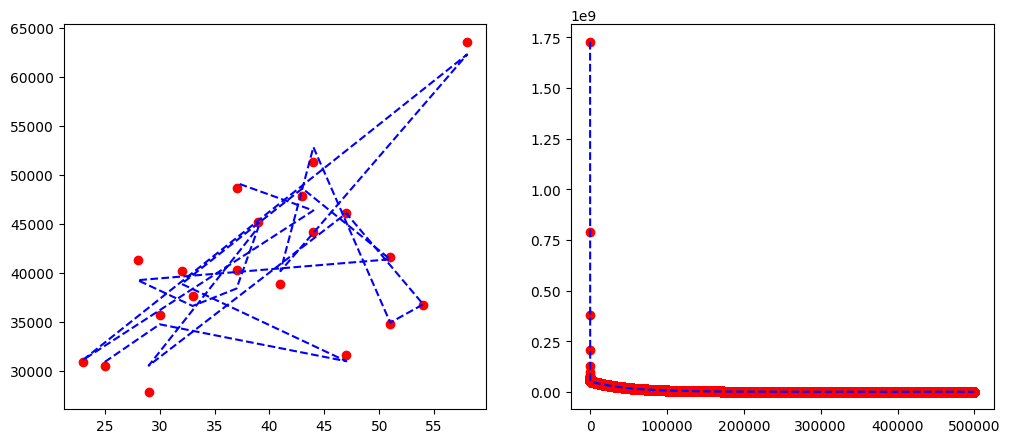

Updated Parameter:
   m1 = -94.88420532679848
 m2 = 2159.172594578223
  c = 31102.3776062692


In [ ]:
#print and plot
print(f"Error: {error}\nGradient: {grad}")
print(f"y:{y}\ny_hat:{y_hat}")


plt.figure(figsize= (12,5))
plt.subplot(1,2,1)
plt.plot(x1, y, "ro")
plt.plot(x1, y_hat, "b--")

plt.subplot(1,2,2)
errors.append(error)
plt.plot(errors, 'ro')
plt.plot(errors, 'b--')

plt.show()

print (f"Updated Parameter:\n   m1 = {m1}\n m2 = {m2}\n  c = {c}")

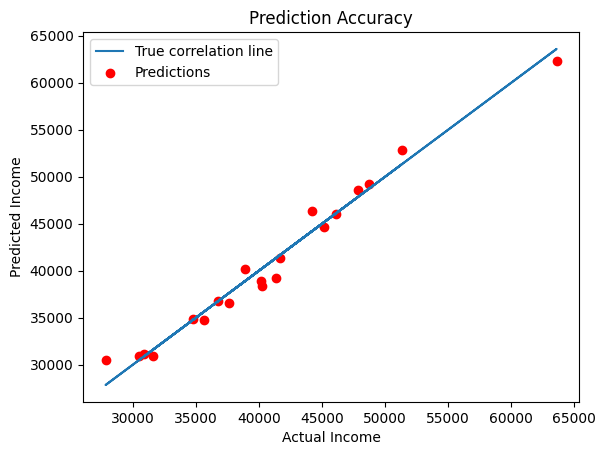

In [ ]:
plt.plot(y, y, label="True correlation line")
plt.scatter(y, y_hat, color="red", label="Predictions")
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Prediction Accuracy")
plt.legend()
plt.show()